# Breakpoints & Step-Through Debugging [Step 3 - State Inspection]

> **MLCourse - Agentic AI - LangGraph**

This notebook demonstrates how to use LangGraph's breakpoint and
step-through debugging features to inspect state at each node,
diagnose issues, and understand graph execution flow.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv("D:/projects/python/MLCourse/03_agentic_ai/.env")

False

In [2]:
groq_key = os.environ.get("GROQ_API_KEY", "")
if groq_key:
    print("GROQ_API_KEY found")
else:
    print("GROQ_API_KEY not set - using ChatOllama (local, no key needed)")

GROQ_API_KEY not set - using ChatOllama (local, no key needed)


In [3]:
# Core imports for breakpoint debugging
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_ollama import ChatOllama

In [4]:
# State schema with debugging fields
class DebugState(TypedDict):
    messages: Annotated[list, add_messages]
    step_log: list
    current_step: str

In [5]:
# Initialize local LLM
llm = ChatOllama(model="llama3.1:8b", temperature=0)

In [6]:
# Node 1 - preprocess: logs entry and cleans input
def preprocess(state: DebugState):
    # Log that this node executed
    log = state.get("step_log", [])
    log.append("preprocess entered")
    return {
        "step_log": log,
        "current_step": "preprocess",
        "messages": [("system", "Input preprocessed for processing.")],
    }

In [7]:
# Node 2 - process: main logic node
def process(state: DebugState):
    log = state.get("step_log", [])
    log.append("process entered")
    response = llm.invoke(state["messages"])
    return {
        "step_log": log,
        "current_step": "process",
        "messages": [response],
    }

In [8]:
# Node 3 - postprocess: formats output
def postprocess(state: DebugState):
    log = state.get("step_log", [])
    log.append("postprocess entered")
    last_msg = state["messages"][-1].content
    formatted = f"[Formatted] {last_msg}"
    return {
        "step_log": log,
        "current_step": "postprocess",
        "messages": [("assistant", formatted)],
    }

In [9]:
# Build the graph
graph_builder = StateGraph(DebugState)
graph_builder.add_node("preprocess", preprocess)
graph_builder.add_node("process", process)
graph_builder.add_node("postprocess", postprocess)
graph_builder.add_edge(START, "preprocess")
graph_builder.add_edge("preprocess", "process")
graph_builder.add_edge("process", "postprocess")
graph_builder.add_edge("postprocess", END)

In [10]:
# Compile with checkpointer for state inspection
checkpointer = MemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

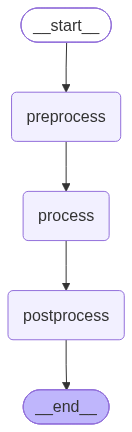

In [11]:
# Visualize the graph
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization unavailable: {e}")
    print("Graph nodes: START -> preprocess -> process -> postprocess -> END")

In [12]:
# Method 1: Step-through debugging via get_state()
# Execute the graph, then inspect state at each checkpoint
config = {"configurable": {"thread_id": "debug-thread-1"}}

# Invoke the full graph
result = graph.invoke(
    {"messages": [("user", "What is 2 + 2?")]},
    config,
)
print("Full execution result:", result["messages"][-1].content[:80])

Full execution result: [Formatted] assistant

The answer to 2 + 2 is 4.


In [13]:
# Inspect the state after execution
# get_state() returns the latest checkpoint with full state
state = graph.get_state(config)
print("\nCurrent state:")
print(f"  Next nodes: {state.next}")
print(f"  Current step: {state.values.get('current_step', 'N/A')}")
print(f"  Step log: {state.values.get('step_log', [])}")


Current state:
  Next nodes: ()
  Current step: postprocess
  Step log: ['preprocess entered', 'process entered', 'postprocess entered']


In [14]:
# Method 2: Checkpoint history for execution trace
# list all checkpoints to see how state evolved at each node
checkpoints = list(graph.get_state_history(config))
print(f"\nExecution trace ({len(checkpoints)} checkpoints):")
for cp in checkpoints:
    step = cp.values.get("current_step", "start")
    log = cp.values.get("step_log", [])
    msg_count = len(cp.values.get("messages", []))
    print(f"  step={step}, messages={msg_count}, log={log}")


Execution trace (5 checkpoints):
  step=postprocess, messages=4, log=['preprocess entered', 'process entered', 'postprocess entered']
  step=process, messages=3, log=['preprocess entered', 'process entered', 'postprocess entered']
  step=preprocess, messages=2, log=['preprocess entered', 'process entered']
  step=start, messages=1, log=[]
  step=start, messages=0, log=[]


In [15]:
# Method 3: Breakpoints with interrupt()
# Add interrupt() calls to pause at specific nodes for inspection

# Build a new graph with breakpoints
def preprocess_breakpoint(state: DebugState):
    # This interrupt acts as a breakpoint - pauses execution here
    interrupt("Breakpoint at preprocess: inspect state before continuing")
    log = state.get("step_log", [])
    log.append("preprocess (after breakpoint)")
    return {
        "step_log": log,
        "current_step": "preprocess",
        "messages": [("system", "Preprocessed with breakpoint.")],
    }

def process_breakpoint(state: DebugState):
    # Another breakpoint in the process node
    interrupt("Breakpoint at process: review LLM input")
    log = state.get("step_log", [])
    log.append("process (after breakpoint)")
    response = llm.invoke(state["messages"])
    return {
        "step_log": log,
        "current_step": "process",
        "messages": [response],
    }

In [16]:
# Build the breakpoint graph
bp_builder = StateGraph(DebugState)
bp_builder.add_node("preprocess", preprocess_breakpoint)
bp_builder.add_node("process", process_breakpoint)
bp_builder.add_node("postprocess", postprocess)
bp_builder.add_edge(START, "preprocess")
bp_builder.add_edge("preprocess", "process")
bp_builder.add_edge("process", "postprocess")
bp_builder.add_edge("postprocess", END)

bp_graph = bp_builder.compile(checkpointer=checkpointer)

In [17]:
# Step through with breakpoints
bp_config = {"configurable": {"thread_id": "bp-debug-thread"}}

# Start - pauses at preprocess breakpoint
result = bp_graph.invoke(
    {"messages": [("user", "Explain breakpoints.")]},
    bp_config,
)
print("Paused at preprocess breakpoint")
state = bp_graph.get_state(bp_config)
print(f"State at breakpoint: step={state.values.get('current_step')}")
print(f"Messages so far: {len(state.values.get('messages', []))}")

Paused at preprocess breakpoint
State at breakpoint: step=None
Messages so far: 1


In [18]:
# Resume past preprocess breakpoint - pauses at process breakpoint
result = bp_graph.invoke(Command(resume="continue"), bp_config)
print("\nPaused at process breakpoint")
state = bp_graph.get_state(bp_config)
print(f"State at breakpoint: step={state.values.get('current_step')}")


Paused at process breakpoint
State at breakpoint: step=preprocess


In [19]:
# Resume past process breakpoint - runs to completion
result = bp_graph.invoke(Command(resume="continue"), bp_config)
print("\nCompleted execution:")
state = bp_graph.get_state(bp_config)
print(f"Final step: {state.values.get('current_step')}")
print(f"Step log: {state.values.get('step_log', [])}")


Completed execution:
Final step: postprocess
Step log: ['preprocess (after breakpoint)', 'process (after breakpoint)', 'postprocess entered']


In [20]:
# Method 4: Manual state inspection pattern
# Useful for diagnosing issues in production graphs
print("\nManual Debugging Pattern:")
print("  1. graph.get_state(config) - view current state")
print("  2. graph.get_state_history(config) - list all checkpoints")
print("  3. interrupt('message') - pause at any node")
print("  4. Command(resume=...) - continue past breakpoint")
print("  5. state.values - access all state fields")
print("  6. state.next - see which node runs next")
print("  7. state.metadata - checkpoint metadata for timestamps")


Manual Debugging Pattern:
  1. graph.get_state(config) - view current state
  2. graph.get_state_history(config) - list all checkpoints
  3. interrupt('message') - pause at any node
  4. Command(resume=...) - continue past breakpoint
  5. state.values - access all state fields
  6. state.next - see which node runs next
  7. state.metadata - checkpoint metadata for timestamps


In [21]:
# Show how to update state manually (useful for fixing stuck graphs)
bp_config2 = {"configurable": {"thread_id": "bp-debug-thread-2"}}
result = bp_graph.invoke(
    {"messages": [("user", "What are breakpoints?")]},
    bp_config2,
)
# Pause at first breakpoint
print("Paused - updating state manually...")
state_before = bp_graph.get_state(bp_config2)
print(f"Current step_log: {state_before.values.get('step_log', [])}")

# Manually update state to add a custom field
bp_graph.update_state(bp_config2, {"current_step": "manual_override"})
state_after = bp_graph.get_state(bp_config2)
print(f"After update: {state_after.values.get('current_step')}")

# Resume to complete
result = bp_graph.invoke(Command(resume="continue"), bp_config2)
result = bp_graph.invoke(Command(resume="continue"), bp_config2)
print("\nCompleted after state override")
print(f"Final step_log: {graph.get_state(bp_config2).values.get('step_log', [])}")

Paused - updating state manually...
Current step_log: []
After update: manual_override



Completed after state override
Final step_log: ['preprocess (after breakpoint)', 'process (after breakpoint)', 'postprocess entered']


In [22]:
# Debugging summary
print("\nBreakpoint Debugging Summary:")
print("  get_state() - inspect state at current checkpoint")
print("  get_state_history() - full execution trace across checkpoints")
print("  interrupt() - pause execution at any node for inspection")
print("  update_state() - manually modify state to fix or test scenarios")
print("  checkpoint metadata includes timestamps and step counts")


Breakpoint Debugging Summary:
  get_state() - inspect state at current checkpoint
  get_state_history() - full execution trace across checkpoints
  interrupt() - pause execution at any node for inspection
  update_state() - manually modify state to fix or test scenarios
  checkpoint metadata includes timestamps and step counts
